# 2

In [ ]:
!pip install pycaret[full]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.6/169.6 kB 6.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of category-encoders to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.9/109.9 kB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 9.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 52.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of flask to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.1/47.1 kB 2.3 MB/s eta 0:00:00
  Preparing meta

In [ ]:
from pycaret.regression import *
from pycaret.datasets import get_data

# 3


# 4

In [ ]:
dataset_name = 'insurance'
dataset = get_data(dataset_name)
print(dataset.shape)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


(1338, 7)


In [ ]:
data = dataset.sample(frac=0.9, random_state=123)
data_unseen = dataset.drop(data.index)
data.reset_index(inplace=True, drop=True)
data_unseen.reset_index(inplace=True, drop=True)
print('Data for Modeling: ' + str(data.shape))
print('Unseen Data For Predictions: ' + str(data_unseen.shape))

Data for Modeling: (1204, 7)
Unseen Data For Predictions: (134, 7)


# 5

In [ ]:
s = setup(data=data, target="charges", session_id=123)

,Description,Value
0,Session id,123
1,Target,charges
2,Target type,Regression
3,Original data shape,"(1204, 7)"
4,Transformed data shape,"(1204, 10)"
5,Transformed train set shape,"(842, 10)"
6,Transformed test set shape,"(362, 10)"
7,Numeric features,3
8,Categorical features,3
9,Preprocess,True


# 6

In [ ]:
compare_models(sort='RMSE', fold=5)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,2491.6552,20285326.4407,4471.4364,0.8619,0.4299,0.3012,0.1100
lightgbm,Light Gradient Boosting Machine,2820.0513,22635563.9268,4728.8521,0.8464,0.5691,0.3667,0.3020
rf,Random Forest Regressor,2656.6028,22660627.0025,4734.4081,0.8460,0.4604,0.3215,0.2660
catboost,CatBoost Regressor,2700.9116,22700313.8922,4740.3926,0.8466,0.4777,0.3269,0.5980
et,Extra Trees Regressor,2575.7996,24414261.0320,4920.3065,0.8351,0.4601,0.3044,0.2260
ada,AdaBoost Regressor,3877.1462,24766879.7008,4961.5624,0.8320,0.6119,0.6800,0.0660
xgboost,Extreme Gradient Boosting,2997.6180,27741690.0000,5254.8169,0.8136,0.5366,0.3908,0.0960
lasso,Lasso Regression,4189.1777,35569896.5109,5959.6639,0.7605,0.5636,0.4363,0.0600
llar,Lasso Least Angle Regression,4189.1797,35569953.7125,5959.6687,0.7605,0.5636,0.4363,0.0580
lar,Least Angle Regression,4188.9978,35572032.1760,5959.8419,0.7605,0.5641,0.4363,0.0580


Processing:   0%|          | 0/85 [00:00<?, ?it/s]

GradientBoostingRegressor(random_state=123)

In [ ]:
compare_models(include=['ridge', 'knn'], sort='RMSE')

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
ridge,Ridge Regression,4203.5881,35521087.9039,5935.8918,0.7487,0.5780,0.4377,0.0550
knn,K Neighbors Regressor,8375.6199,138211371.2000,11674.4912,0.0736,0.8535,0.9570,0.0610


Processing:   0%|          | 0/13 [00:00<?, ?it/s]

Ridge(random_state=123)

# 7

In [ ]:
ridge = create_model('ridge')
print(ridge)

knn = create_model('knn')
print(knn)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,4182.1373,35401077.9684,5949.8805,0.7744,0.7602,0.4592
1,3944.9433,26452404.4226,5143.1901,0.8601,0.4062,0.4534
2,4296.4480,32290104.5761,5682.4383,0.7499,0.4943,0.4421
3,4214.2585,40596824.1914,6371.5637,0.6500,0.7534,0.4214
4,4590.5067,43949373.4255,6629.4324,0.7219,0.5548,0.3331
5,3688.4829,26539533.9107,5151.6535,0.8154,0.4165,0.3790
6,4823.6582,42493624.0333,6518.7134,0.7665,0.5975,0.4448
7,3919.1805,35806862.8576,5983.8836,0.6652,0.6610,0.4670
8,4180.0979,29639387.8983,5444.2068,0.8536,0.4925,0.5194


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

Ridge(random_state=123)


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,9552.0674,178585424.0000,13363.5859,-0.1378,0.8988,0.9914
1,9865.5186,197346112.0000,14047.9932,-0.0438,0.9772,1.2073
2,8760.4131,137919920.0000,11743.9316,-0.0681,0.9138,1.0749
3,6846.1108,90265640.0000,9500.8232,0.2219,0.7623,0.7492
4,8637.8623,143507536.0000,11979.4629,0.0918,0.8503,0.7107
5,7336.7485,116570696.0000,10796.7910,0.1892,0.7169,0.7892
6,8991.7021,158908032.0000,12605.8730,0.1267,0.8161,0.8060
7,7833.9971,101164992.0000,10058.0811,0.0540,0.9226,1.3104
8,8535.1631,147674544.0000,12152.1416,0.2707,0.8448,0.9717


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

KNeighborsRegressor(n_jobs=-1)


# 8

In [ ]:
tuned_ridge = tune_model(ridge)
print(tuned_ridge)

tuned_knn = tune_model(knn)
print(tuned_knn)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,4177.9560,35375707.3882,5947.7481,0.7746,0.8226,0.4587
1,3931.4066,26359661.7118,5134.1661,0.8606,0.4049,0.4516
2,4289.6641,32298268.2274,5683.1565,0.7499,0.4928,0.4410
3,4213.9747,40698895.1146,6379.5686,0.6492,0.7858,0.4210
4,4588.8592,44034960.9687,6635.8843,0.7213,0.5580,0.3332
5,3678.6667,26506408.5751,5148.4375,0.8156,0.4161,0.3773
6,4813.9908,42444119.3219,6514.9151,0.7667,0.6097,0.4440
7,3913.5592,35866774.7484,5988.8876,0.6646,0.6725,0.4651
8,4165.0907,29514739.7084,5432.7470,0.8542,0.4909,0.5168


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).
Ridge(random_state=123)


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,7373.1424,111754727.9293,10571.4109,0.2880,0.7095,0.7254
1,8519.3601,141871179.7136,11910.9689,0.2496,0.7973,0.9103
2,7486.7498,100506137.9937,10025.2750,0.2217,0.7223,0.7836
3,6369.0518,76576247.1417,8750.7855,0.3399,0.6755,0.6799
4,7865.3897,115379338.1305,10741.4775,0.2698,0.7076,0.6101
5,6842.3907,92815756.8623,9634.0935,0.3544,0.6719,0.7340
6,7930.0972,124941660.3625,11177.7306,0.3133,0.6821,0.6851
7,6380.4978,69262257.7725,8322.3950,0.3523,0.7848,1.0144
8,8328.6257,131324643.2331,11459.6965,0.3515,0.7931,0.9484


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


KNeighborsRegressor(metric='manhattan', n_jobs=-1, n_neighbors=13,
                    weights='distance')


# 9

In [ ]:
predict_model(tuned_ridge)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Ridge Regression,4234.9661,38106935.9914,6173.0816,0.7112,0.5685,0.4542


,age,sex,bmi,children,smoker,region,charges,prediction_label
630,40,male,29.900000,2,no,southwest,6600.360840,8392.647992
228,54,male,30.020000,0,no,northwest,24476.478516,11565.906755
136,32,female,28.930000,0,no,southeast,3972.924805,5222.317340
685,47,male,36.080002,1,yes,southeast,42211.136719,35437.335282
971,29,male,29.639999,1,no,northeast,20277.806641,5859.947146
...,...,...,...,...,...,...,...,...
274,31,male,39.490002,1,no,southeast,3875.734131,8705.986893
691,63,male,33.660000,3,no,southeast,15161.534180,15744.030255
907,41,male,29.639999,5,no,northeast,9222.402344,10627.750968
317,40,male,19.799999,1,yes,southeast,17179.521484,28051.314835


# 10

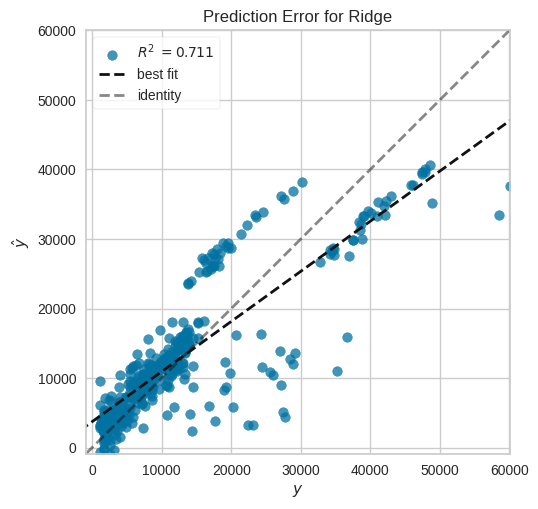

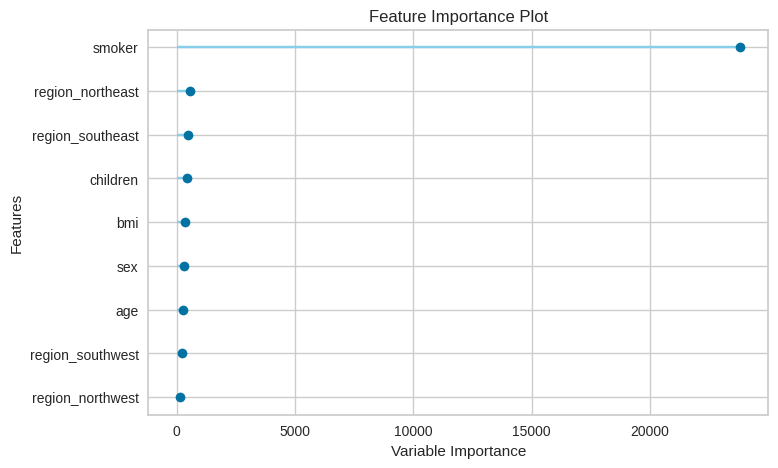

In [ ]:
plot_model(tuned_ridge, plot='error')
plot_model(tuned_ridge, plot='feature')

# 11

In [ ]:
final_ridge = finalize_model(tuned_ridge)

# 12

In [ ]:
unseen_predicitions = predict_model(final_ridge, data=data_unseen)
unseen_predicitions.head()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Ridge Regression,4464.5295,44772173.5775,6691.2012,0.7068,0.5842,0.3461


,age,sex,bmi,children,smoker,region,charges,prediction_label
0,31,female,25.740000,0,no,southeast,3756.621582,3728.995735
1,37,female,27.740000,3,no,northwest,7281.505371,8163.314403
2,56,female,39.820000,0,no,southeast,11090.717773,15074.517559
3,23,male,23.844999,0,no,northeast,2395.171631,1846.165868
4,19,female,28.600000,5,no,southwest,4687.796875,4379.384856


# 13

In [ ]:
save_model(final_ridge, 'Final Ridge Regression Model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['age', 'bmi', 'children'],
                                     transformer=SimpleImputer())),
                 ('categorical_imputer',
                  TransformerWrapper(include=['sex', 'smoker', 'region'],
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('ordinal_encoding',
                  TransformerWrapper(include=['sex', 'smoker'],
                                     transfor...
                                                                mapping=[{'col': 'sex',
                                                                          'data_type': dtype('O'),
                                                                          'mapping': female    0
 male      1
 NaN      -1
 dtype: int64},
                                                                         {'col': 'smoker',
     

# 14

In [ ]:
saved_final_ridge = load_model('Final Ridge Regression Model')
new_predicition = predict_model(saved_final_ridge,
                                # data=data_new
                                )
  # data_new is just an example
new_predicition.head()

Transformation Pipeline and Model Successfully Loaded


NameError: name 'data_new' is not defined

# Questions


1. Why B-fold cross-validation

Estimates the performance of a model by training and validating on subsets of data. Trainings on subsets then validating on remaining subsets. Allows to approximate how well the model generalizes using the average of B performances.


---


2. The hyper-parameter for a Ridge Regression

Alpha is the strength of regularization. When alpha is *zero* it's more like linear regression and *w* becomes large. When alpha is *large* the penalty is larger and *w* becomes small.


---


3. The hyper-parameter for K-nearest neighbour regression

(a)

Number of neighbours used for prediction

(b)

Makes it so all the data points is the nearest neighbour, thus creating so all the predictions are the same.


---


4. Compare performance metrics after final parameter tuning

(a)

Ridge regression. Less overfitting, generalizes bettwe, computational efficient, better at high-dimensional data.

(b)

TEXT


---


5. Pros and cons when choosing the number of folds B in B-fold cross validation

(a)

With more folds comes more computational power.

(b)

Leave-one-out makes it so the training sets are near identical.
B = 2 results in a large difference between the different training sets.


---


6. Why avoiding the use of compare_models

(a)

If using wrong parameters, compare_models will disregard the wrong model because of the parameters.

(b)

So the models gets their optimal parameters first to then compare it to the others, this ensures that the best model will be found


---


7. Why avoiding the use of the function finalize_model

(a)

Hyper-parameter tuning was based on smaller training sets during cross-validation. Using all data for training may invalidate the chosen parameters.

(b)

Once all data is used for training, there is no independent test data left to estimate performance unless an external dataset is available
